In [1]:
import os

from tqdm.notebook import tqdm

import numpy as np
from matplotlib import pyplot as plt
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.special import erf
from scipy.stats import norm

import kemstem

In [2]:
def calculate_R(raw_data, regressed):
    sse = np.sum(np.square(raw_data - regressed))
    sst = np.sum(np.square(raw_data - raw_data.mean()))
    return 1 - sse/sst

def fit(f, xdata, ydata, plot=False, **kwargs):
    xdata = np.array(xdata).flatten()
    ydata = np.array(ydata).flatten()
    if plot:
        plt.plot(xdata, ydata, 'k.')
        if 'sigma' in kwargs:
            plt.errorbar(xdata, ydata, kwargs['sigma'], fmt='none', c='k')
    popt, pcov = curve_fit(f, xdata, ydata, **kwargs)
    perr = np.sqrt(np.diag(pcov))
    R = calculate_R(ydata, f(xdata, *popt))
    if plot:
        xlim, ylim = plt.xlim(), plt.ylim()
        plt.xlim(*xlim)
        plt.ylim(*ylim)
        x = np.linspace(*xlim, 100)
        plt.plot(x, f(x, *popt), 'r--')
        plt.show()
    return popt, perr, R

In [4]:
results = loadmat('./Si2V1-Niter1000.mat')
# results = loadmat('./Si5V2-Niter1000.mat')
# results = loadmat('./Si8V2-Niter1000.mat')

In [5]:
roi = results['p']['object_ROI'][0][0][0]
roix = roi[0].T
roiy = roi[1]

DZ = results['outputs']['z_distance'].item().item()

recon_object = results['object'][roix, roiy]
print(recon_object.shape)

(573, 573, 20)


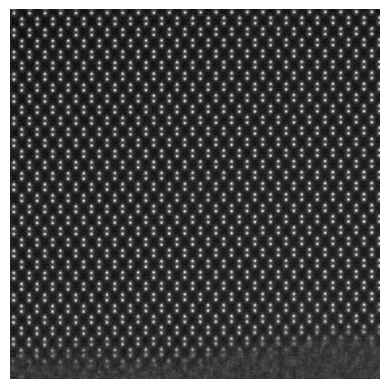

In [6]:
LAYER = 11

plt.imshow(np.angle(recon_object[:, :, LAYER]), cmap='gray')
plt.axis('off')
plt.show()

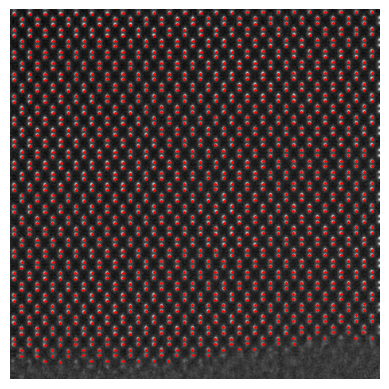

1465 columns found


In [7]:
image = np.angle(recon_object[:,:,LAYER])

blurred_image = gaussian_filter(image, 1)
distance = 2
threshold = 0.5

c0 = kemstem.find_columns(blurred_image, distance=distance, threshold=threshold)

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.plot(c0[:, 1], c0[:, 0], 'r.', markersize=2)
plt.show()
print(f'{c0.shape[0]} columns found')

In [8]:
# test_it = 100
# window_dim = 5
# cf,errs,opts,data_fits = kemstem.refine_columns(blurred_image,c0[test_it,:],window_dim)

# visualization_window = 5*window_dim
# fig,ax = plt.subplots(2,2,constrained_layout=True)
# ax[0,0].matshow(data_fits[:,:,0,0],cmap='gray')
# ax[0,1].matshow(data_fits[:,:,0,1],cmap='gray')
# ax[1,0].matshow(blurred_image,cmap='gray')
# ax[1,0].plot(c0[test_it,1],c0[test_it,0],'b.') # original unfit position shown in blue
# ax[1,0].plot(cf[0,1],cf[0,0],'r.') # fit position shown in red
# ax[1,0].set_xlim([c0[test_it,1]-visualization_window,c0[test_it,1]+visualization_window])
# ax[1,0].set_ylim([c0[test_it,0]+visualization_window,c0[test_it,0]-visualization_window])
# ax[1,1].matshow(data_fits[:,:,0,0]-data_fits[:,:,0,1],cmap='gray',vmin=-.1,vmax=.1) # fit residual
# _ = [tax.axis('off') for tax in ax.ravel()]

In [9]:
# cf, errs, opts, data_fits = kemstem.refine_columns(image, c0, window_dim)

In [10]:
# plt.imshow(image, cmap='gray')
# plt.axis('off')
# plt.plot(cf[:, 1], cf[:, 0], 'r.', markersize=2)
# plt.show()
# print(f'Refined columns')

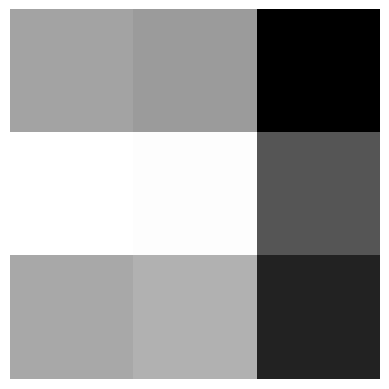

In [11]:
WINDOW = 1
cx, cy = c0[len(c0) // 2]
wx_start, wx_end = cx-WINDOW, cx+WINDOW+1
wy_start, wy_end = cy-WINDOW, cy+WINDOW+1
plt.imshow(np.angle(recon_object)[wx_start:wx_end, wy_start:wy_end, LAYER], cmap='gray')
plt.axis('off')
plt.show()

In [12]:
columns = []

for i, (cx, cy) in enumerate(tqdm(c0)):
    wx_start, wx_end = cx-WINDOW, cx+WINDOW+1
    wy_start, wy_end = cy-WINDOW, cy+WINDOW+1
    column = np.angle(recon_object)[wx_start:wx_end, wy_start:wy_end, 1:].mean(axis=(0, 1))
    columns.append(column)

  0%|          | 0/1465 [00:00<?, ?it/s]

In [13]:
def double_erf(x, p0, p1, q, x0, h):
    return p0 + p1 * (erf(q*(x - x0)) - erf(q*(x - x0 - h)))

In [14]:
def gaussian_plus_linear(x, p0, p1, q, mu, s):
    linear = p0 + p1 * x
    gauss  = q * norm.pdf(x, mu, s)
    return linear + gauss

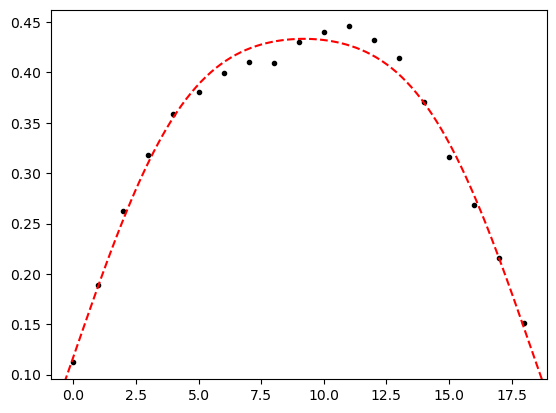

[-0.18965366  0.31451085  0.20175432  0.10413929 18.18937594]


In [15]:
# bounds = [[-0.2, 0, 0, -5, 0], [0.3, 1, 10, 15, 25]]

for i in [800]:
    popt0, _, _ = fit(
        double_erf, np.arange(len(columns[0])), columns[i], plot=True,
        p0=[0.1, 0.05, 1, 1, 15],
        # bounds=bounds,
        )
    print(popt0)


  0%|          | 0/1465 [00:00<?, ?it/s]

(0.0, 300.0)

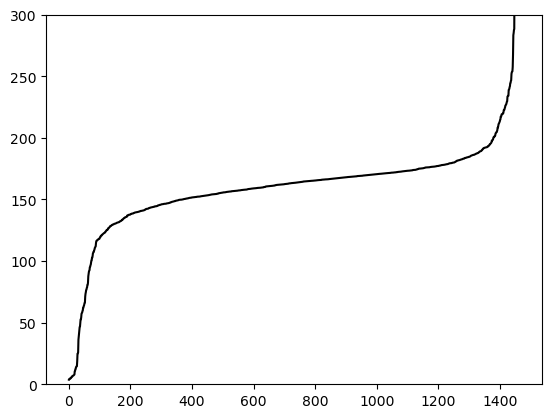

In [16]:
heights = []


for column in tqdm(columns):
    popt, perr, _ = fit(
        double_erf, np.arange(len(column)), column, plot=False,
        p0=popt0,
        # bounds=bounds,
        maxfev=10000
        )
    h, dh = popt[-1], perr[-1]
    heights.append(h * DZ)


heights = np.array(heights)

plt.plot(np.sort(heights), 'k')
plt.ylim(0, 300)

In [21]:
heights[(heights < 190) & (heights > 140)]

array([186.28758807, 159.46389009, 189.36394664, ..., 158.93214468,
       148.67459386, 145.31492308], shape=(1115,))

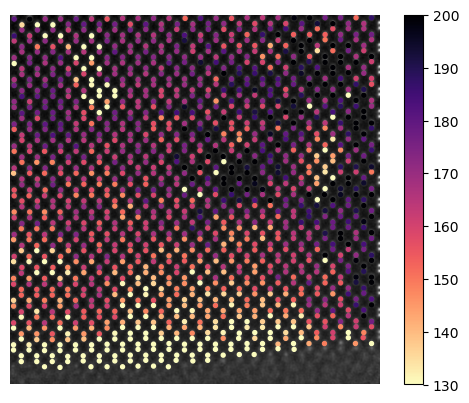

In [ ]:
plt.imshow(np.angle(recon_object).sum(axis=-1), cmap='gray')
plt.axis('off')
plt.scatter(
    c0[:, 1][(heights < 190) & (heights > 140)], c0[:, 0][(heights < 190) & (heights > 140)], c=np.array(heights[(heights < 190) & (heights > 140)]), s=8, cmap='magma_r',
    vmax=190, 
    vmin=140
    )

cbar = plt.colorbar()

plt.show()